# OMR for Jazz Lead Sheets — Pipeline Walkthrough

**Pol Casanovas Puig** · TFG, FIB-UPC, 2026 · Director: Manel Frigola Bourlon

In [68]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import sys, os, warnings
from pathlib import Path

_here = Path().resolve()
ROOT  = _here.parent if _here.name == "notebooks" else _here
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, matplotlib.gridspec as gridspec
import textwrap, torch, cv2
from PIL import Image

import style; style.apply()

from CRNN_CTC.config   import Config
from CRNN_CTC.vocab    import Vocabulary
from CRNN_CTC.model    import CRNN
from CRNN_CTC.evaluate import greedy_decode

cfg   = Config()
vocab = Vocabulary.from_file(cfg.vocab_path)

DATA_AA   = ROOT / "data/realbook_primus_aa"
DATA_AB   = ROOT / "data/realbook_primus_ab"
DATA_SCAN = ROOT / "data/realbook_primus_aa_scanned"
PRIMUS    = ROOT / "data/primus/package_aa"
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Sample used throughout
SID  = "000051650-1_1_1"
SDIR = DATA_AA / SID

print(f"Device : {DEVICE}")
print(f"Vocab  : {len(vocab)} tokens")
print(f"Dataset: {sum(1 for _ in DATA_AA.iterdir())} + {sum(1 for _ in DATA_AB.iterdir())} samples (aa + ab)")

Device : cuda
Vocab  : 100 tokens
Dataset: 43591 + 44077 samples (aa + ab)


## 1 — The Goal: Image → Token Sequence

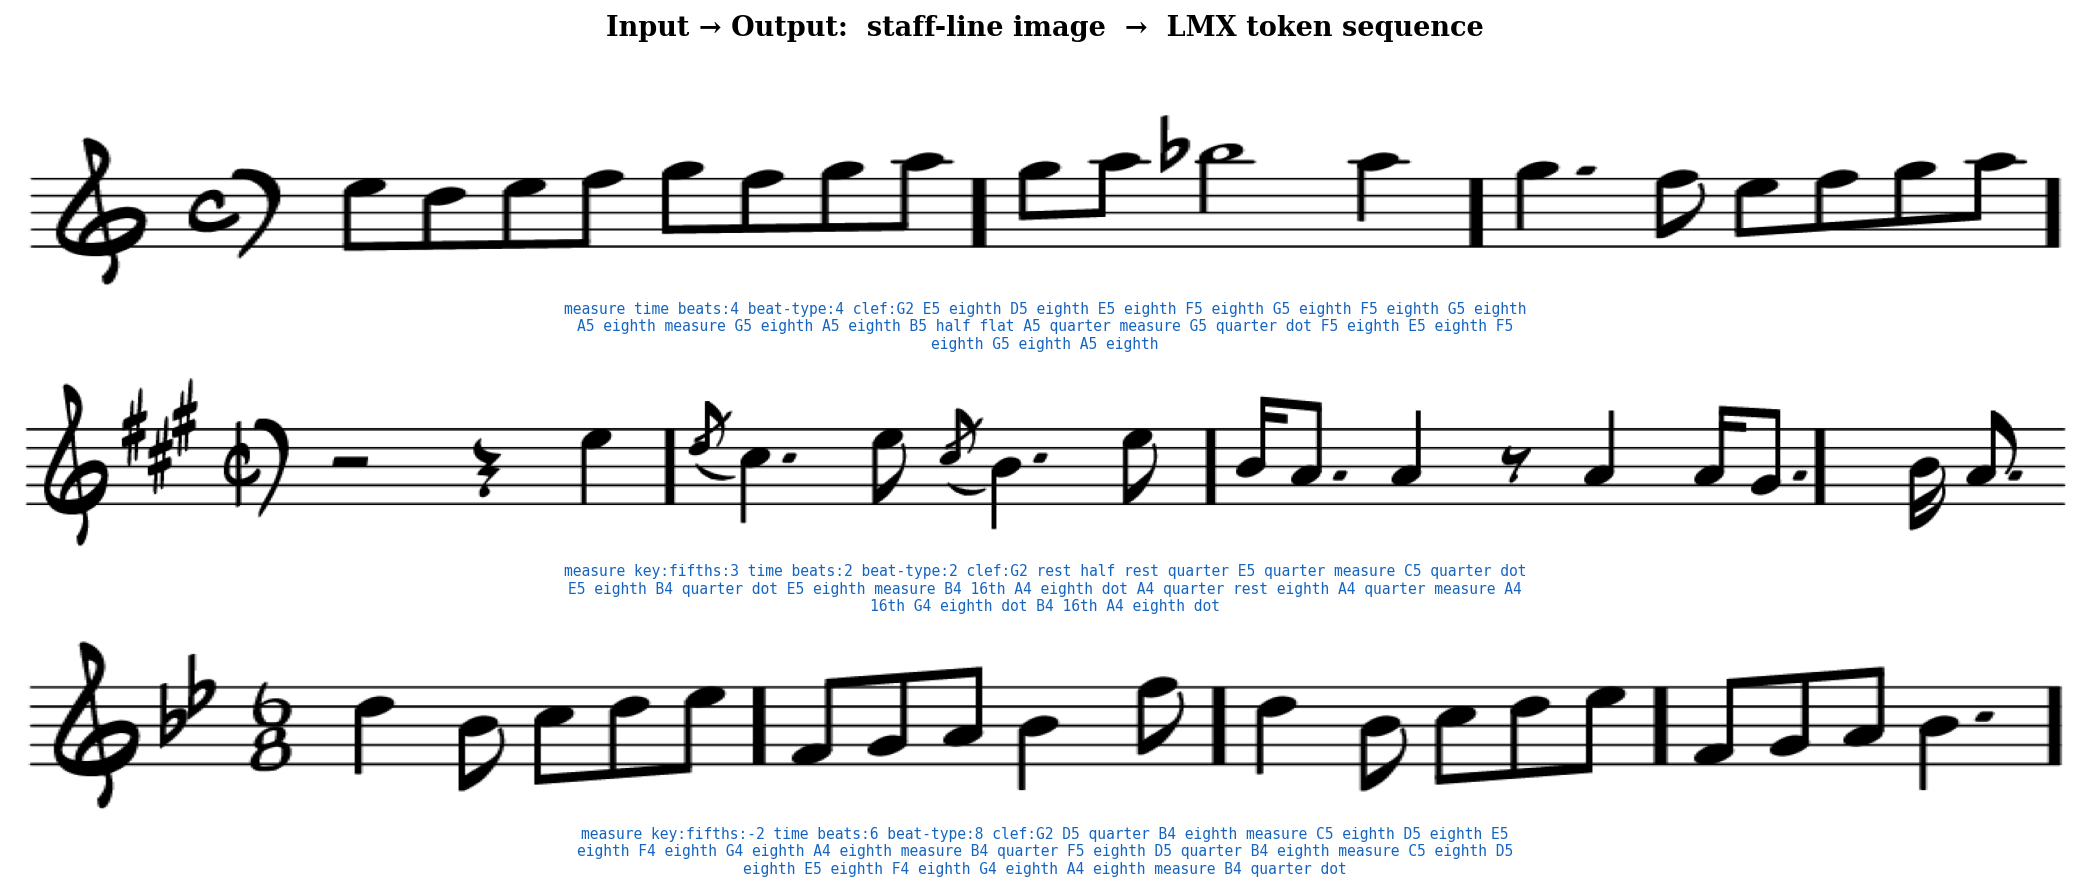

In [69]:
# Three random samples: image on top, LMX tokens below
import random; random.seed(42)
samples = random.sample(sorted(DATA_AA.iterdir()), 3)

fig, axes = plt.subplots(3, 1, figsize=(14, 6))
fig.suptitle("Input → Output:  staff-line image  →  LMX token sequence",
             fontsize=13, fontweight="bold", y=0.98)

for ax, sdir in zip(axes, samples):
    sid  = sdir.name
    img  = np.array(Image.open(sdir / f"{sid}.png").convert("L"))
    toks = (sdir / f"{sid}.lmx").read_text().strip().split()
    wrapped = textwrap.fill(" ".join(toks), width=110)

    ax.imshow(img, cmap="gray", aspect="auto")
    ax.set_xlabel(wrapped, fontsize=7, family="monospace",
                  color=style.C["primary"], labelpad=4)
    ax.set_yticks([]); ax.set_xticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 2 — Data Generation: PrIMuS → LilyJAZZ Re-render

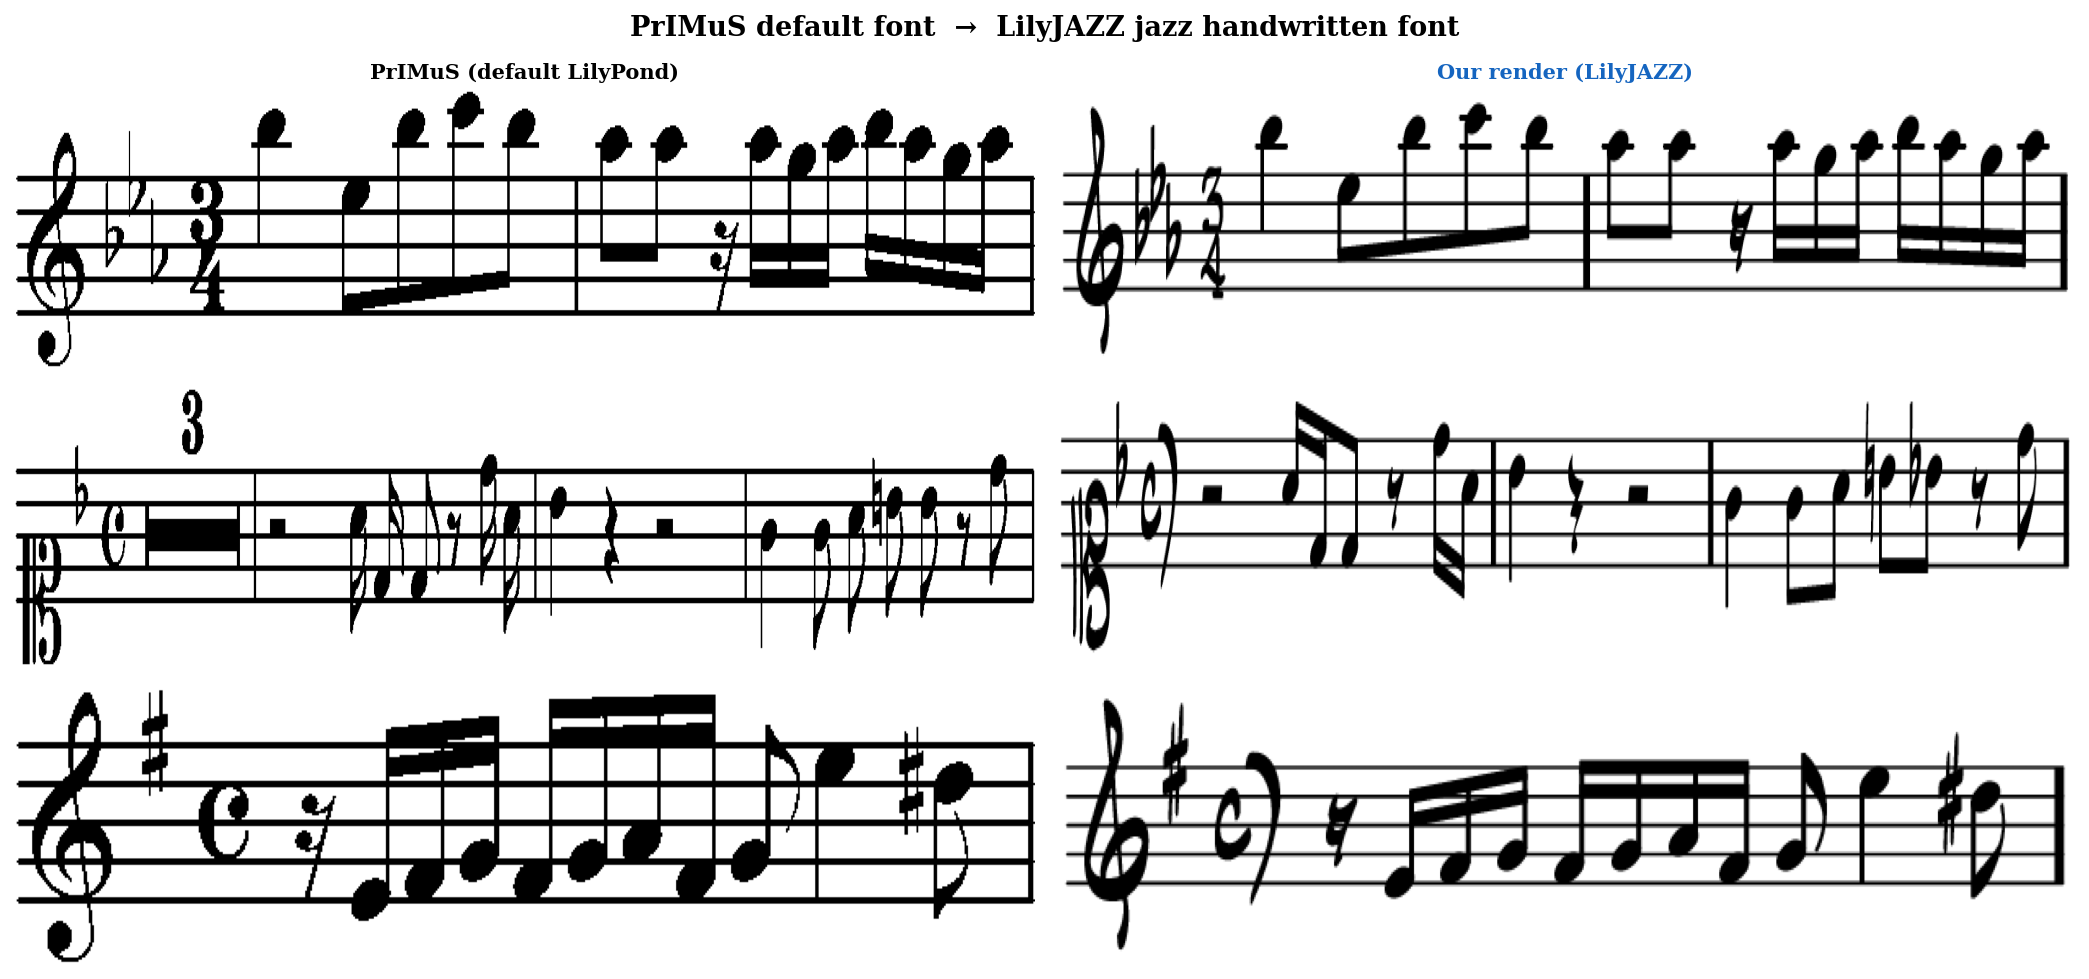

In [70]:
# PrIMuS default typeset  vs.  our LilyJAZZ re-render (three examples)
demo_sids = ["000051650-1_1_1", "000051656-1_1_1", "000051770-1_1_1"]

fig, axes = plt.subplots(len(demo_sids), 2, figsize=(14, len(demo_sids) * 2.2))
fig.suptitle("PrIMuS default font  →  LilyJAZZ jazz handwritten font",
             fontsize=13, fontweight="bold")

for row, sid in enumerate(demo_sids):
    primus_png = PRIMUS / sid / f"{sid}.png"
    our_png    = DATA_AA / sid / f"{sid}.png"

    if primus_png.exists():
        axes[row, 0].imshow(np.array(Image.open(primus_png).convert("L")),
                            cmap="gray", aspect="auto")
    else:
        axes[row, 0].text(0.5, 0.5, "not found", ha="center", va="center",
                          transform=axes[row, 0].transAxes)

    axes[row, 1].imshow(np.array(Image.open(our_png).convert("L")),
                        cmap="gray", aspect="auto")

    for c in range(2):
        axes[row, c].axis("off")

axes[0, 0].set_title("PrIMuS (default LilyPond)", fontsize=10, fontweight="bold")
axes[0, 1].set_title("Our render (LilyJAZZ)", fontsize=10, fontweight="bold",
                      color=style.C["primary"])

plt.tight_layout()
plt.show()

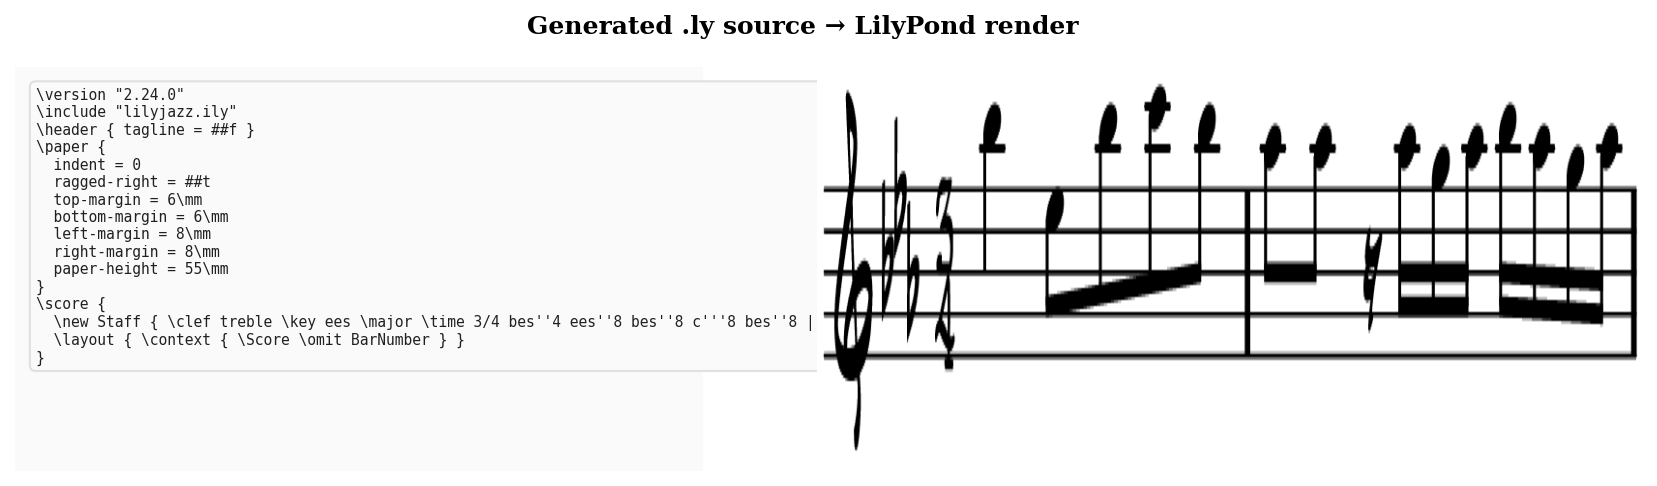

In [71]:
# LilyPond source file → rendered output (one example)
our_png = SDIR / f"{SID}.png"
ly_source = (SDIR / f"{SID}.ly").read_text().strip()

fig = plt.figure(figsize=(14, 3.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.15)
fig.suptitle("Generated .ly source → LilyPond render", fontsize=12, fontweight="bold")

ax0 = fig.add_subplot(gs[0])
ax0.set_facecolor(style.C["bg_figure"])
for sp in ax0.spines.values(): sp.set_visible(False)
ax0.set_xticks([]); ax0.set_yticks([])
ax0.text(0.03, 0.95, ly_source, transform=ax0.transAxes,
         fontsize=7, va="top", family="monospace", color=style.C["neutral_dark"],
         bbox=dict(boxstyle="round,pad=0.4", fc=style.C["bg_figure"], ec=style.C["neutral_light"]))

ax1 = fig.add_subplot(gs[1])
ax1.imshow(np.array(Image.open(our_png).convert("L")), cmap="gray", aspect="auto")
ax1.axis("off")

plt.tight_layout()
plt.show()

## 3 — LMX Encoding

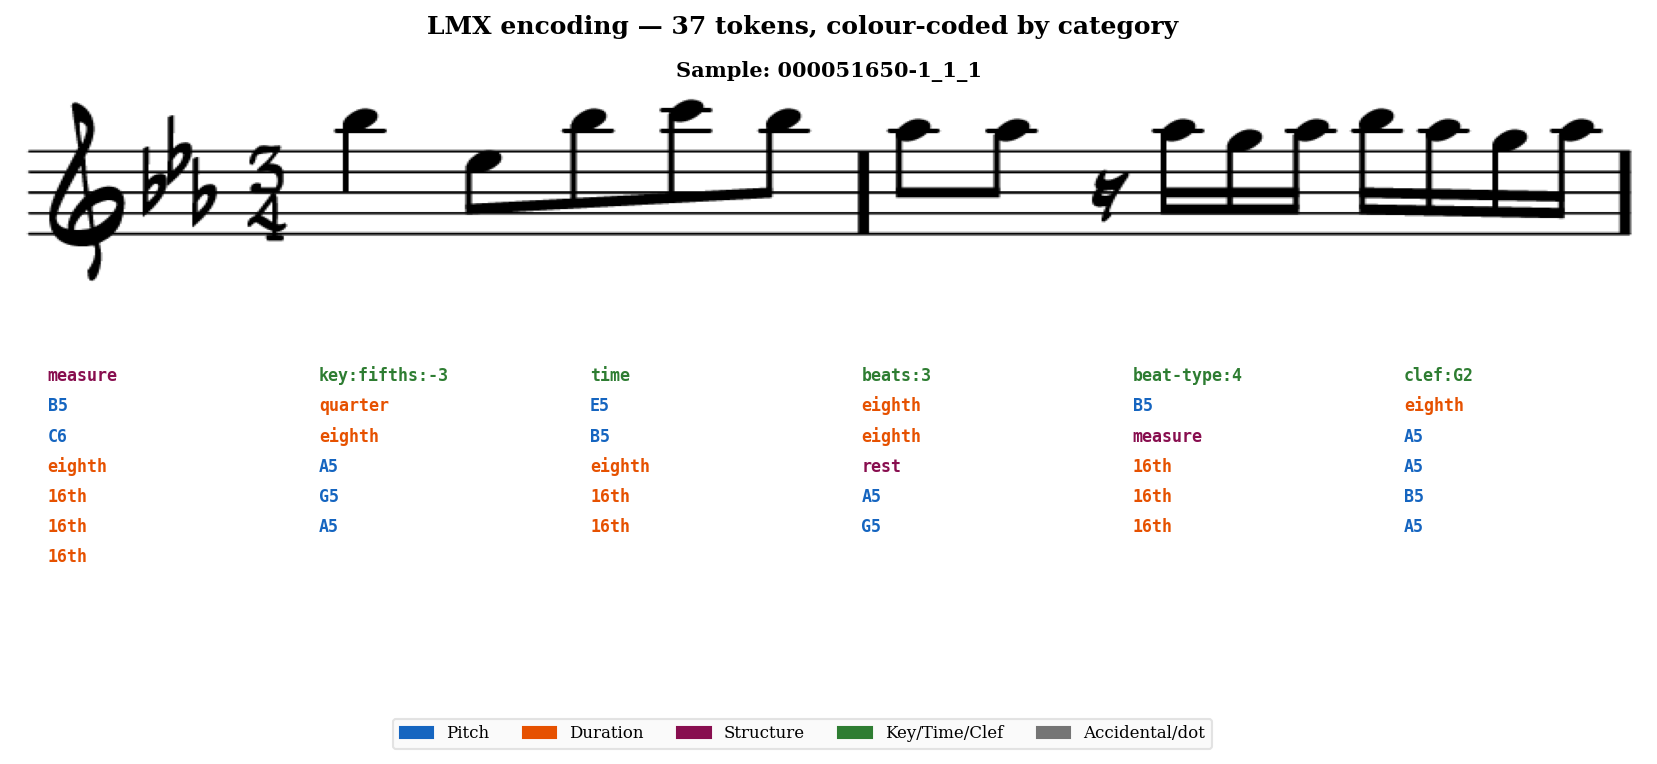

In [72]:
# Colour-coded token categories for the sample
semantic = (SDIR / f"{SID}.semantic").read_text().strip()
lmx      = (SDIR / f"{SID}.lmx").read_text().strip()
sem_toks = semantic.split("\t")
lmx_toks = lmx.split()

# Category colouring
CAT_COLOR = {
    "pitch":    style.C["primary"],
    "duration": style.C["secondary"],
    "struct":   style.C["highlight"],
    "header":   style.C["tertiary"],
    "acc":      style.C["neutral_mid"],
}
PITCH_SET  = {t for t in vocab._idx2tok[2:] if len(t) == 2 and t[0] in "ABCDEFG" and t[1].isdigit()}
DUR_SET    = {"whole", "half", "quarter", "eighth", "16th", "32nd", "64th", "128th", "256th", "breve", "long", "3in2"}
STRUCT_SET = {"measure", "rest", "rest:measure", "forward", "tied:start", "tied:stop", "tuplet:start", "tuplet:stop"}
ACC_SET    = {"flat", "sharp", "natural", "dot"}

def tok_color(t):
    if t in PITCH_SET:  return CAT_COLOR["pitch"]
    if t in DUR_SET:    return CAT_COLOR["duration"]
    if t in STRUCT_SET: return CAT_COLOR["struct"]
    if t in ACC_SET:    return CAT_COLOR["acc"]
    return CAT_COLOR["header"]

# ── Layout: image on top, colour-coded tokens below ──────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 1.5], hspace=0.3)

# Staff-line image
ax_img = fig.add_subplot(gs[0])
ax_img.imshow(np.array(Image.open(SDIR / f"{SID}.png").convert("L")),
              cmap="gray", aspect="auto")
ax_img.axis("off")
ax_img.set_title(f"Sample: {SID}", fontsize=10, fontweight="bold")

# Colour-coded LMX tokens
ax_tok = fig.add_subplot(gs[1])
ax_tok.set_axis_off()
for i, tok in enumerate(lmx_toks):
    row, col = divmod(i, 6)
    ax_tok.text(col / 6 + 0.02, 0.95 - row * 0.1, tok,
                transform=ax_tok.transAxes, fontsize=8, family="monospace",
                color=tok_color(tok), fontweight="bold")

# Legend
handles = [mpatches.Patch(color=CAT_COLOR[k], label=l) for k, l in
           [("pitch", "Pitch"), ("duration", "Duration"), ("struct", "Structure"),
            ("header", "Key/Time/Clef"), ("acc", "Accidental/dot")]]
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=8,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

plt.suptitle(f"LMX encoding — {len(lmx_toks)} tokens, colour-coded by category",
             fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.show()

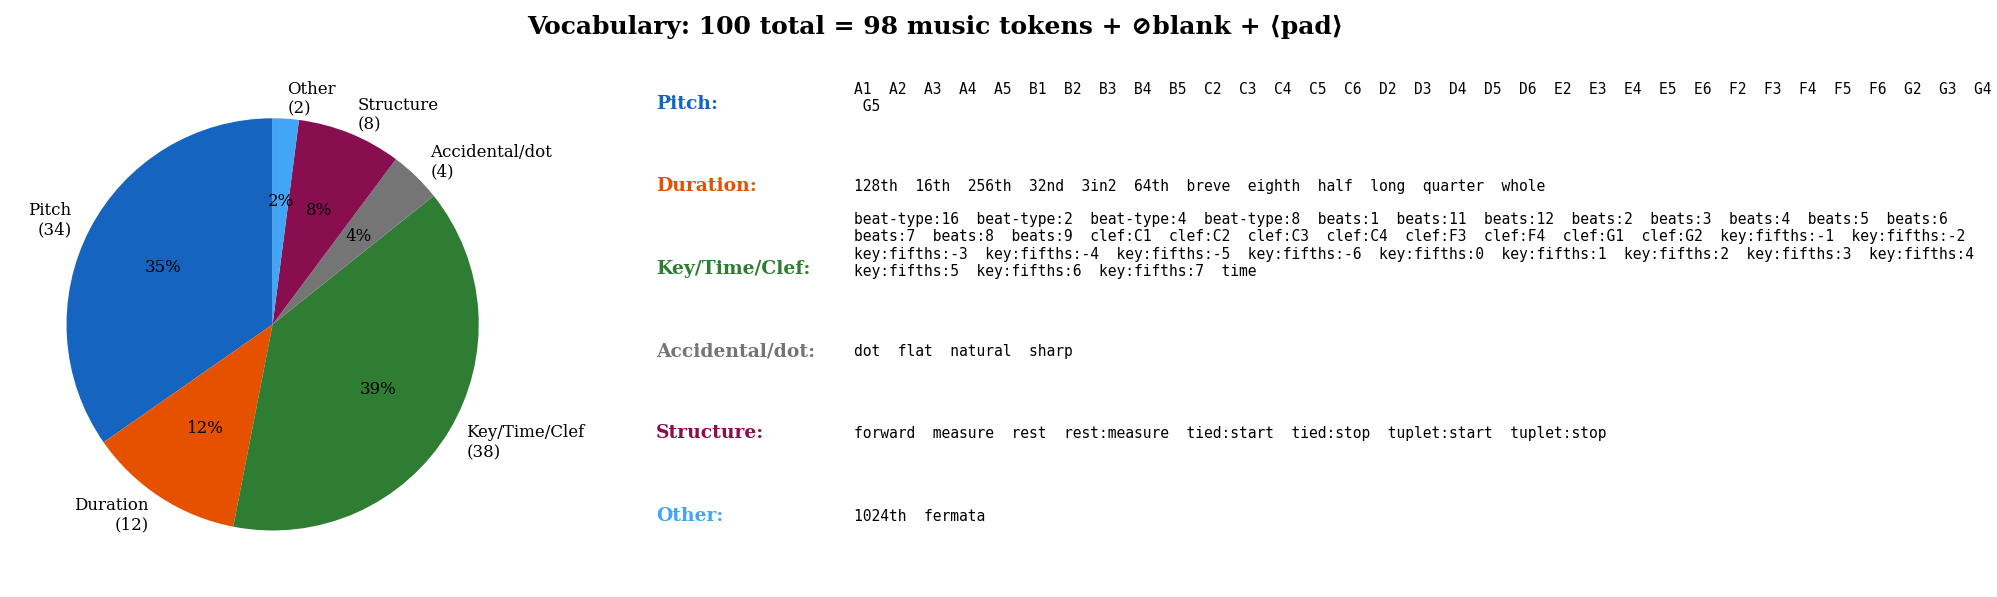

In [73]:
# Vocabulary distribution — pie chart by category + full list
all_toks = vocab._idx2tok[2:]  # skip blank + pad
categories = {
    "Pitch":          [t for t in all_toks if t in PITCH_SET],
    "Duration":       [t for t in all_toks if t in DUR_SET],
    "Key/Time/Clef":  [t for t in all_toks if t.startswith(("key:", "time", "clef:", "beats:", "beat-type:"))],
    "Accidental/dot": [t for t in all_toks if t in ACC_SET],
    "Structure":      [t for t in all_toks if t in STRUCT_SET],
}
other_toks = [t for t in all_toks if not any(t in v for v in categories.values())]
if other_toks:
    categories["Other"] = other_toks

cat_colors = [style.C["primary"], style.C["secondary"], style.C["tertiary"],
              style.C["neutral_mid"], style.C["highlight"], style.C["primary_light"]]

fig, (ax_pie, ax_list) = plt.subplots(1, 2, figsize=(14, 4),
                                       gridspec_kw={"width_ratios": [1, 1.5]})
fig.suptitle(f"Vocabulary: {len(vocab)} total = {len(all_toks)} music tokens + ⊘blank + ⟨pad⟩",
             fontsize=12, fontweight="bold")

# Pie
sizes  = [len(v) for v in categories.values()]
labels = [f"{k}\n({n})" for k, n in zip(categories.keys(), sizes)]
ax_pie.pie(sizes, labels=labels, colors=cat_colors[:len(sizes)],
           autopct="%1.0f%%", textprops={"fontsize": 8}, startangle=90)

# Full list
ax_list.set_axis_off()
for i, (cat, toks) in enumerate(categories.items()):
    ax_list.text(0.0, 0.92 - i * 0.16, f"{cat}:", fontsize=9, fontweight="bold",
                 color=cat_colors[i], transform=ax_list.transAxes)
    ax_list.text(0.18, 0.92 - i * 0.16, "  ".join(toks), fontsize=7,
                 family="monospace", transform=ax_list.transAxes, wrap=True)

plt.tight_layout()
plt.show()

## 4 — Scan Simulation (Data Augmentation)

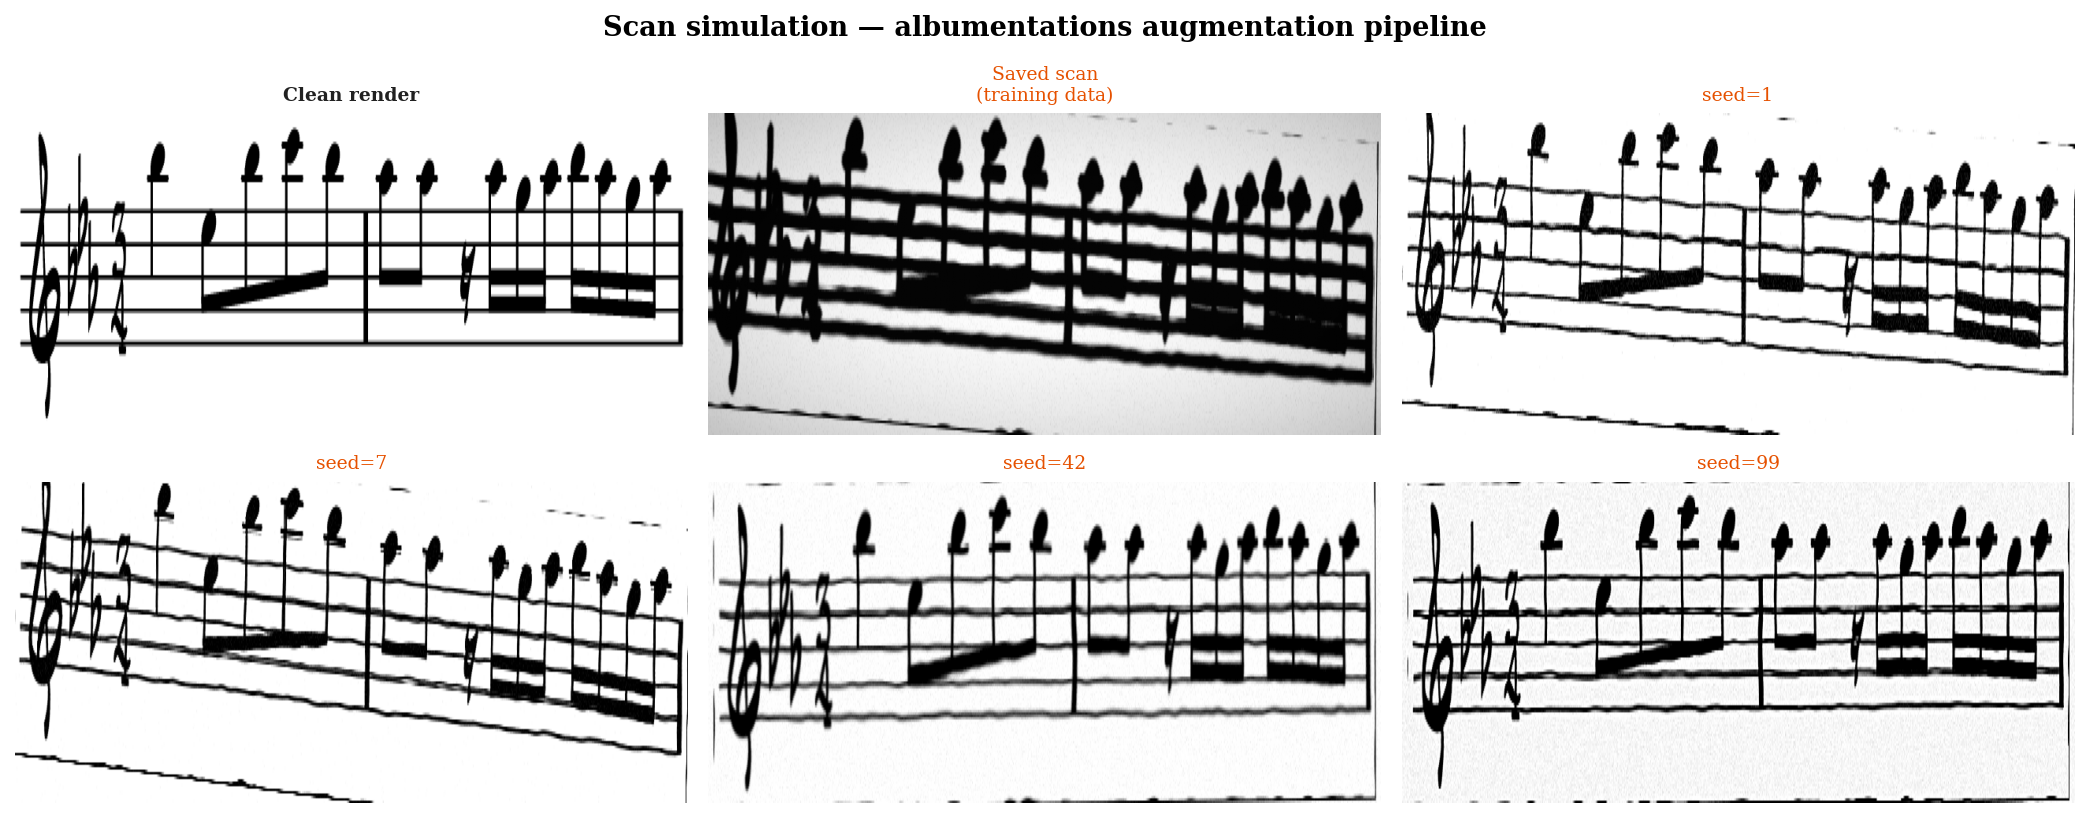

In [74]:
import albumentations as A

def build_aug_pipeline(seed):
    return A.Compose([
        A.ElasticTransform(alpha=28, sigma=5, p=0.90),
        A.GridDistortion(num_steps=5, distort_limit=(-0.10, 0.10), p=0.80),
        A.Affine(rotate=(-3.0, 3.0), scale=(0.98, 1.02),
                 border_mode=cv2.BORDER_CONSTANT, fill=255, p=0.90),
        A.GaussianBlur(blur_limit=0, sigma_limit=(0.3, 0.8), p=0.70),
        A.Sharpen(alpha=(0.2, 0.5), lightness=(0.85, 1.0), p=0.55),
        A.RandomToneCurve(scale=0.15, p=0.80),
        A.GaussNoise(std_range=(0.02, 0.06), mean_range=(0.0, 0.0),
                     per_channel=False, p=0.85),
        A.RandomBrightnessContrast(brightness_limit=(-0.10, 0.05),
                                   contrast_limit=(0.05, 0.20), p=0.90),
    ], seed=seed)

clean_u8 = cv2.imread(str(SDIR / f"{SID}.png"), cv2.IMREAD_GRAYSCALE)

# Pre-saved scan + 4 live augmentations
scan_p     = DATA_SCAN / SID / f"{SID}.png"
saved_scan = cv2.imread(str(scan_p), cv2.IMREAD_GRAYSCALE) if scan_p.exists() else None
seeds      = [1, 7, 42, 99]
augmented  = [build_aug_pipeline(s)(image=clean_u8)["image"] for s in seeds]

# ── Grid: clean | saved scan | 4 augmentations ──────────────────────────────
cols = ["Clean render", "Saved scan\n(training data)"] + [f"seed={s}" for s in seeds]
images = [clean_u8, saved_scan] + augmented

fig, axes = plt.subplots(2, 3, figsize=(14, 5.5))
fig.suptitle("Scan simulation — albumentations augmentation pipeline",
             fontsize=13, fontweight="bold")

for i, (ax, im, title) in enumerate(zip(axes.flat, images, cols)):
    if im is not None:
        ax.imshow(im, cmap="gray", aspect="auto")
    ax.set_title(title, fontsize=9,
                 fontweight="bold" if i == 0 else "normal",
                 color=style.C["secondary"] if i > 0 else style.C["neutral_dark"])
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5 — Image Preprocessing

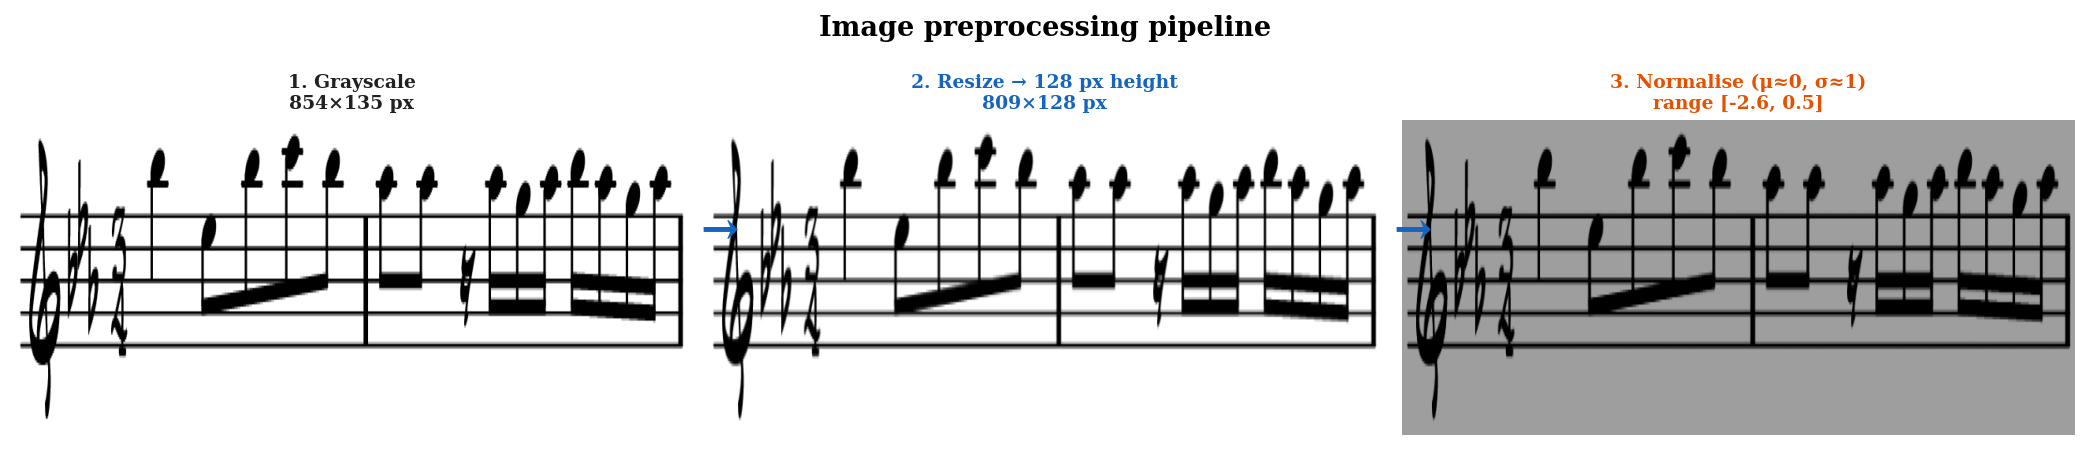

Output tensor: (1, 128, 809)


In [ ]:
# Preprocessing pipeline: grayscale → resize → normalise
raw_gray = cv2.imread(str(SDIR / f"{SID}.png"), cv2.IMREAD_GRAYSCALE)

H_TARGET = 128
scale    = H_TARGET / raw_gray.shape[0]
new_w    = min(int(raw_gray.shape[1] * scale), 2048)
resized  = cv2.resize(raw_gray, (new_w, H_TARGET), interpolation=cv2.INTER_AREA)

img_f = resized.astype(np.float32) / 255.0
mu, sig = img_f.mean(), img_f.std()
norm = (img_f - mu) / (sig + 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
fig.suptitle("Image preprocessing pipeline", fontsize=13, fontweight="bold")

steps = [
    (raw_gray, f"1. Grayscale\n{raw_gray.shape[1]}x{raw_gray.shape[0]} px", {}),
    (resized,  f"2. Resize → {H_TARGET} px height\n{new_w}x{H_TARGET} px", {}),
    (norm,     f"3. Normalise (μ≈0, σ≈1)\nrange [{norm.min():.1f}, {norm.max():.1f}]",
               {"vmin": -2, "vmax": 2}),
]
colors = [style.C["neutral_dark"], style.C["primary"], style.C["secondary"]]
for ax, (im, title, kw), col in zip(axes, steps, colors):
    ax.imshow(im, cmap="gray", aspect="auto", **kw)
    ax.set_title(title, fontsize=9, color=col)
    ax.axis("off")

# Arrows between stages
for i in range(2):
    fig.text(0.345 + i * 0.33, 0.5, "→", fontsize=22, ha="center", va="center",
             color=style.C["primary"], fontweight="bold")

plt.tight_layout()
plt.show()
print(f"Output tensor: (1, {H_TARGET}, {new_w})")

## 6 — CRNN-CTC Architecture

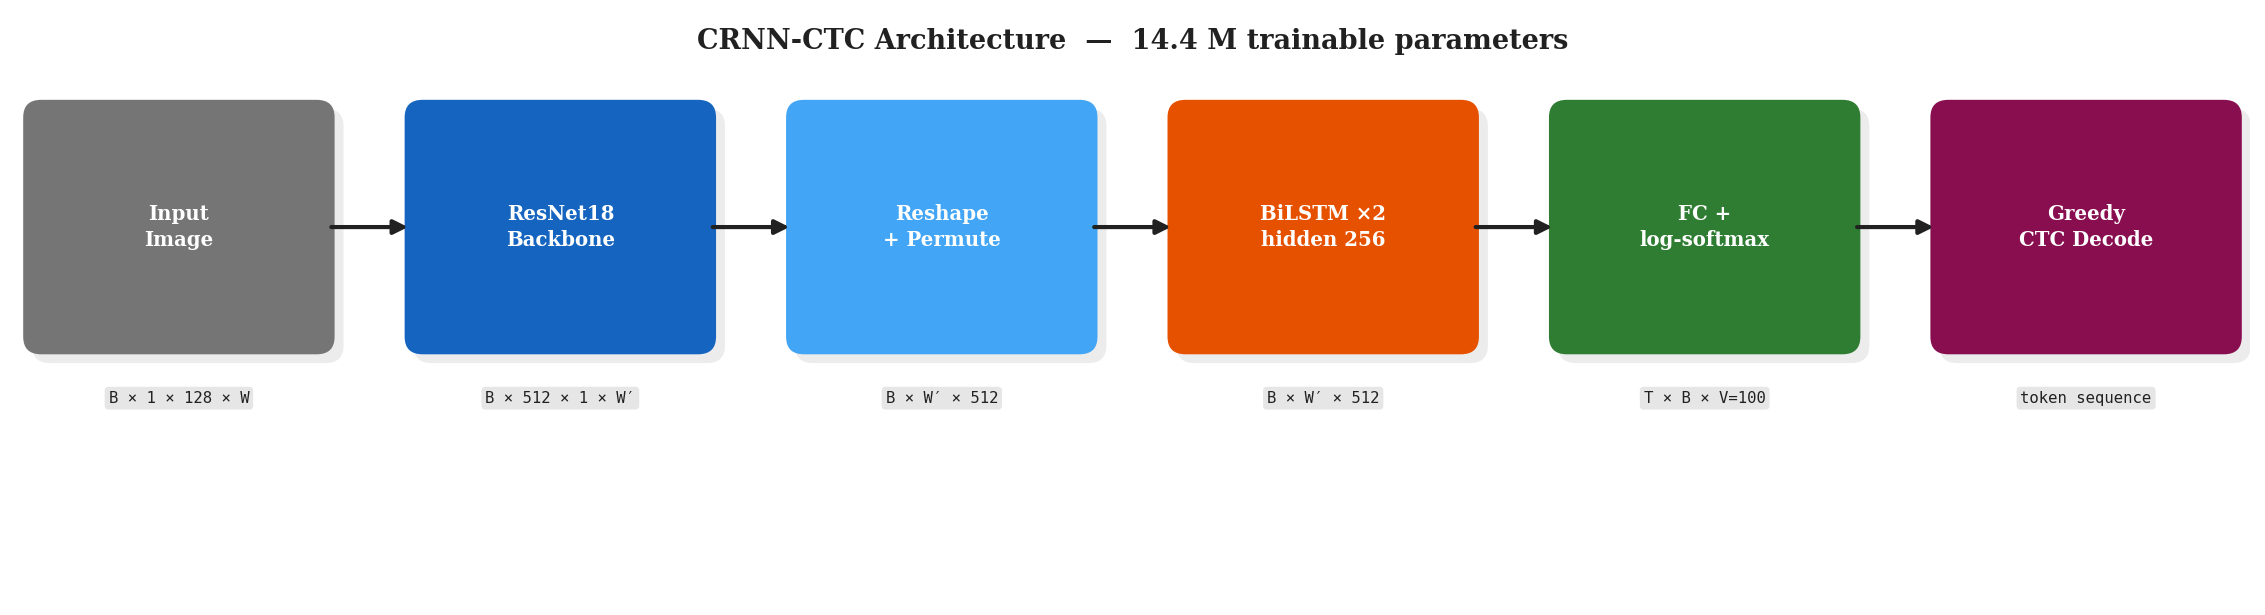

In [ ]:
# Architecture diagram — horizontal pipeline, shapes below boxes
fig, ax = plt.subplots(figsize=(15, 4.0))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_xlim(0, 15); ax.set_ylim(0, 4.0)
ax.axis("off")

ARCH = [
    ("Input\nImage",          "B x 1 x 128 x W",    style.C["neutral_mid"]),
    ("ResNet18\nBackbone",    "B x 512 x 1 x W′",   style.C["primary"]),
    ("Reshape\n+ Permute",    "B x W′ x 512",        style.C["primary_light"]),
    ("BiLSTM x2\nhidden 256", "B x W′ x 512",        style.C["secondary"]),
    ("FC +\nlog-softmax",     "T x B x V=100",       style.C["tertiary"]),
    ("Greedy\nCTC Decode",    "token sequence",       style.C["highlight"]),
]

n   = len(ARCH)
xs  = [1.1 + i * (15.0 - 2.2) / (n - 1) for i in range(n)]
BW, BH, CY = 1.85, 1.50, 2.55   # box width, height, vertical centre

for i, ((lbl, shape, fc), x) in enumerate(zip(ARCH, xs)):
    # drop-shadow
    ax.add_patch(mpatches.FancyBboxPatch(
        (x - BW/2 + 0.06, CY - BH/2 - 0.06), BW, BH,
        boxstyle="round,pad=0.12", facecolor=style.C["neutral_light"],
        edgecolor="none", zorder=2, alpha=0.60))
    # main block
    ax.add_patch(mpatches.FancyBboxPatch(
        (x - BW/2, CY - BH/2), BW, BH,
        boxstyle="round,pad=0.12", facecolor=fc,
        edgecolor="none", zorder=3))
    # label
    ax.text(x, CY, lbl, ha="center", va="center",
            fontsize=9.5, fontweight="bold", color="white",
            zorder=4, linespacing=1.35)
    # tensor shape — pill tag below box
    ax.text(x, CY - BH/2 - 0.42, shape, ha="center", va="center",
            fontsize=7.5, family="monospace", color=style.C["neutral_dark"],
            zorder=4,
            bbox=dict(boxstyle="round,pad=0.25", facecolor=style.C["neutral_light"],
                      edgecolor="none", alpha=0.8))

# arrows
for i in range(n - 1):
    ax.annotate("", xy=(xs[i+1] - BW/2 - 0.07, CY),
                xytext=(xs[i] + BW/2 + 0.07, CY),
                arrowprops=dict(arrowstyle="-|>", color=style.C["neutral_dark"],
                                lw=2.0, mutation_scale=14), zorder=5)

ax.text(7.5, 3.82, "CRNN-CTC Architecture",
        ha="center", va="center", fontsize=13, fontweight="bold",
        color=style.C["neutral_dark"])

plt.tight_layout(pad=0.4)
plt.show()

In [ ]:
# Model instantiation + shape trace through a forward pass
model = CRNN(
    vocab_size=len(vocab), cnn_out_channels=cfg.cnn_out_channels,
    rnn_hidden=cfg.rnn_hidden, rnn_layers=cfg.rnn_layers,
    dropout=cfg.dropout, cnn_dropout=cfg.cnn_dropout, backbone=cfg.backbone,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

with torch.no_grad():
    dummy = torch.randn(1, 1, 128, new_w)
    lp, ol = model(dummy, torch.tensor([new_w]))

T, B, V = lp.shape
print(f"Backbone    : ResNet18  (asymmetric strides, H→1, W→W/4)")
print(f"BiLSTM      : {cfg.rnn_layers} layers x {cfg.rnn_hidden} hidden x 2 directions")
print(f"Parameters  : {trainable:,} trainable")
print(f"Input shape : (1, 1, 128, {new_w})")
print(f"Output shape: (T={T}, B={B}, V={V})   [T ≈ W/4 = {new_w}÷4 = {new_w//4}]")

Backbone    : ResNet18  (asymmetric strides, H→1, W→W/4)
BiLSTM      : 2 layers × 256 hidden × 2 directions
Parameters  : 14,375,460 trainable
Input shape : (1, 1, 128, 809)
Output shape: (T=203, B=1, V=100)   [T ≈ W/4 = 809÷4 = 202]


## 7 — CTC: Alignment-Free Training

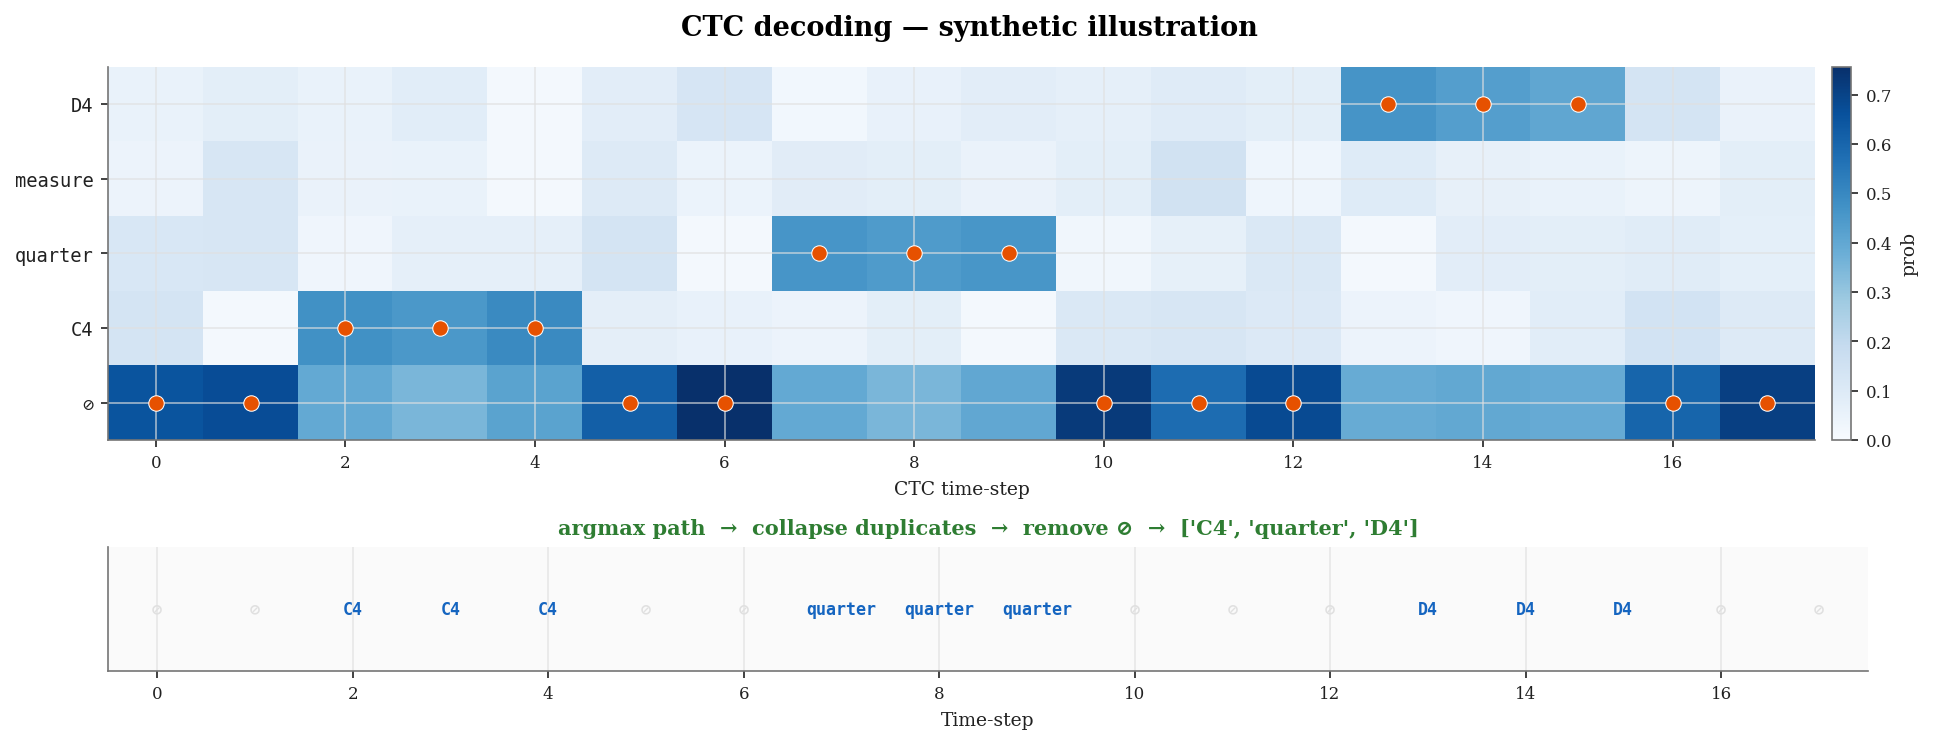

In [78]:
# CTC decoding — synthetic toy illustration
TOY_VOCAB = ["⊘", "C4", "quarter", "measure", "D4"]
TARGET    = ["C4", "quarter", "D4"]
T_DEMO    = 18
V_DEMO    = len(TOY_VOCAB)

rng   = np.random.default_rng(7)
probs = rng.uniform(0.01, 0.12, (T_DEMO, V_DEMO))

# Blank baseline + signal peaks
for t in range(T_DEMO): probs[t, 0] += 0.45
for t in [2, 3, 4]:     probs[t, 1] += 0.55  # C4
for t in [7, 8, 9]:     probs[t, 2] += 0.55  # quarter
for t in [13, 14, 15]:  probs[t, 4] += 0.55  # D4
probs /= probs.sum(axis=1, keepdims=True)

# Greedy decode
raw_path  = [np.argmax(probs[t]) for t in range(T_DEMO)]
collapsed, prev = [], -1
for idx in raw_path:
    if idx != prev: collapsed.append(idx)
    prev = idx
decoded = [TOY_VOCAB[i] for i in collapsed if i != 0]

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 5),
                          gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle("CTC decoding — synthetic illustration", fontsize=13, fontweight="bold")

# Heatmap
im = axes[0].imshow(probs.T, aspect="auto", cmap="Blues",
                    vmin=0, vmax=probs.max(), origin="lower")
axes[0].set_yticks(range(V_DEMO))
axes[0].set_yticklabels(TOY_VOCAB, fontsize=9, family="monospace")
axes[0].set_xlabel("CTC time-step", fontsize=9)
plt.colorbar(im, ax=axes[0], fraction=0.02, pad=0.01, label="prob")

for t, idx in enumerate(raw_path):
    axes[0].scatter(t, idx, s=55, color=style.C["secondary"], zorder=5, edgecolors="white", linewidth=0.5)

# Decode trace
axes[1].set_xlim(-0.5, T_DEMO - 0.5); axes[1].set_ylim(-0.3, 1.3)
axes[1].set_yticks([]); axes[1].set_xlabel("Time-step", fontsize=9)
axes[1].set_facecolor(style.C["bg_figure"])
for t, idx in enumerate(raw_path):
    tok = TOY_VOCAB[idx]
    col = style.C["neutral_light"] if tok == "⊘" else style.C["primary"]
    axes[1].text(t, 0.5, tok, ha="center", va="center",
                fontsize=8, family="monospace", color=col, fontweight="bold")

axes[1].set_title(
    f"argmax path  →  collapse duplicates  →  remove ⊘  →  {decoded}",
    fontsize=10, color=style.C["tertiary"], fontweight="bold")

plt.tight_layout()
plt.show()

## 8 — Training Progress: Run 4 vs Run 5

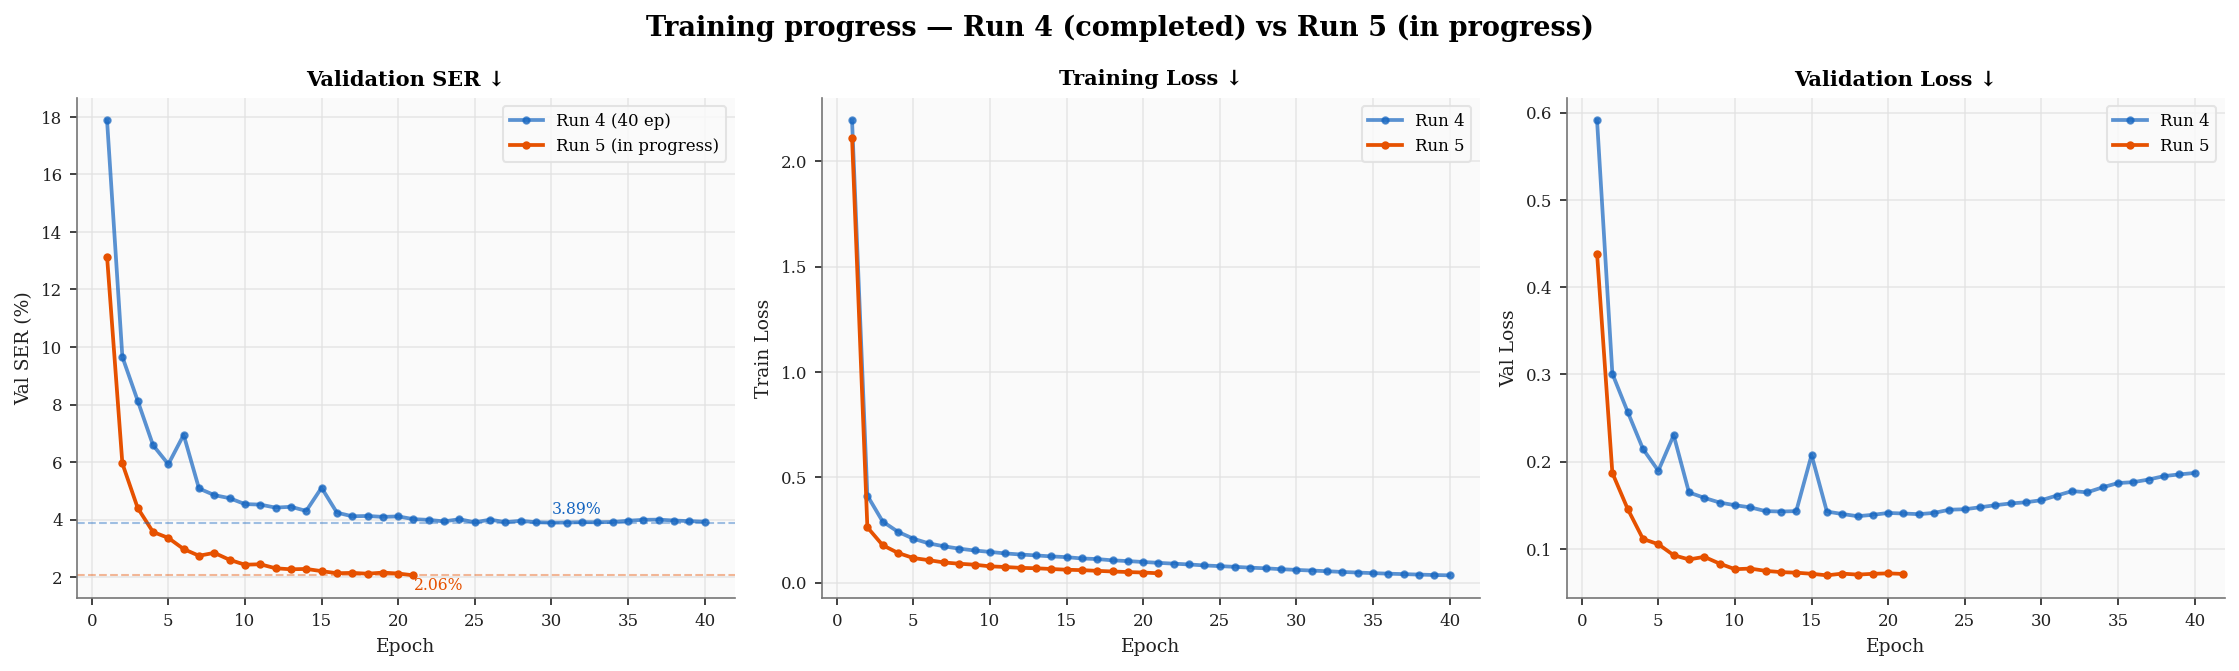

Run 4 best val SER: 3.89%  (epoch 30)
Run 5 best val SER: 2.06%  (epoch 21, still training)


In [79]:
# Training curves — Run 4 (40 epochs, completed) vs Run 5 (19 epochs so far)
run4_path = ROOT / "models/latest/training_log.csv"
run5_path = ROOT / "models/run_20260309_070331/training_log.csv"

run4 = pd.read_csv(run4_path)
run5 = pd.read_csv(run5_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Training progress — Run 4 (completed) vs Run 5 (in progress)",
             fontsize=13, fontweight="bold")

# ── Val SER ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(run4["epoch"], run4["val_ser"] * 100, "-o", ms=3, label="Run 4 (40 ep)",
        color=style.C["primary"], alpha=0.7)
ax.plot(run5["epoch"], run5["val_ser"] * 100, "-o", ms=3, label="Run 5 (in progress)",
        color=style.C["secondary"])
ax.axhline(run4["val_ser"].min() * 100, ls="--", color=style.C["primary"], alpha=0.4, lw=1)
ax.axhline(run5["val_ser"].min() * 100, ls="--", color=style.C["secondary"], alpha=0.4, lw=1)
ax.set_xlabel("Epoch"); ax.set_ylabel("Val SER (%)")
ax.set_title("Validation SER ↓", fontsize=10)
ax.legend(fontsize=8)
ax.text(run4["val_ser"].idxmin() + 1, run4["val_ser"].min() * 100 + 0.3,
        f'{run4["val_ser"].min()*100:.2f}%', fontsize=7.5, color=style.C["primary"])
ax.text(run5["val_ser"].idxmin() + 1, run5["val_ser"].min() * 100 - 0.5,
        f'{run5["val_ser"].min()*100:.2f}%', fontsize=7.5, color=style.C["secondary"])

# ── Train loss ───────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(run4["epoch"], run4["train_loss"], "-o", ms=3, label="Run 4",
        color=style.C["primary"], alpha=0.7)
ax.plot(run5["epoch"], run5["train_loss"], "-o", ms=3, label="Run 5",
        color=style.C["secondary"])
ax.set_xlabel("Epoch"); ax.set_ylabel("Train Loss")
ax.set_title("Training Loss ↓", fontsize=10)
ax.legend(fontsize=8)

# ── Val loss ─────────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(run4["epoch"], run4["val_loss"], "-o", ms=3, label="Run 4",
        color=style.C["primary"], alpha=0.7)
ax.plot(run5["epoch"], run5["val_loss"], "-o", ms=3, label="Run 5",
        color=style.C["secondary"])
ax.set_xlabel("Epoch"); ax.set_ylabel("Val Loss")
ax.set_title("Validation Loss ↓", fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Run 4 best val SER: {run4['val_ser'].min()*100:.2f}%  (epoch {run4['val_ser'].idxmin()+1})")
print(f"Run 5 best val SER: {run5['val_ser'].min()*100:.2f}%  (epoch {run5['val_ser'].idxmin()+1}, still training)")

## 9 — End-to-End Inference

In [80]:
# Load checkpoint and run inference on our sample
CKPT = ROOT / "models/latest/best_model.pt"

ckpt = torch.load(CKPT, map_location=DEVICE, weights_only=False)
ep_loaded  = ckpt.get("epoch", "?")
ser_loaded = ckpt.get("val_ser", float("nan"))
print(f"Checkpoint: epoch {ep_loaded}, val SER {ser_loaded:.4f}")

inf_model = CRNN(
    vocab_size=ckpt.get("vocab_size", len(vocab)),
    cnn_out_channels=cfg.cnn_out_channels, rnn_hidden=cfg.rnn_hidden,
    rnn_layers=cfg.rnn_layers, dropout=0.0, cnn_dropout=0.0,
    backbone=cfg.backbone,
).to(DEVICE)
inf_model.load_state_dict(ckpt["model_state_dict"])
inf_model.eval()

# Prepare input
img_tensor = torch.tensor(norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
img_w      = torch.tensor([img_tensor.shape[-1]])

# Hook for CNN features
cnn_features = {}
hook = inf_model.cnn.features[-2].register_forward_hook(
    lambda mod, inp, out: cnn_features.update({"output": out.detach().cpu()}))

with torch.inference_mode():
    log_probs, out_lens = inf_model(img_tensor.to(DEVICE), img_w.to(DEVICE))
hook.remove()

gt_toks   = (SDIR / f"{SID}.lmx").read_text().strip().split()
pred_toks = greedy_decode(log_probs.cpu(), out_lens.cpu(), vocab)[0]

# Compute SER for this sample
from CRNN_CTC.evaluate import _edit_distance
ser = _edit_distance(pred_toks, gt_toks) / max(len(gt_toks), 1)
print(f"\nGround truth ({len(gt_toks)} tok): {' '.join(gt_toks)}")
print(f"Prediction   ({len(pred_toks)} tok): {' '.join(pred_toks)}")
print(f"SER: {ser:.4f} ({ser*100:.2f}%)")

Checkpoint: epoch 21, val SER 0.0206

Ground truth (37 tok): measure key:fifths:-3 time beats:3 beat-type:4 clef:G2 B5 quarter E5 eighth B5 eighth C6 eighth B5 eighth measure A5 eighth A5 eighth rest 16th A5 16th G5 16th A5 16th B5 16th A5 16th G5 16th A5 16th
Prediction   (36 tok): measure time beats:4 beat-type:2 clef:G2 B5 quarter E5 eighth B5 eighth C6 eighth B5 eighth measure A5 eighth A5 eighth rest 16th A5 eighth G5 eighth A5 eighth B5 eighth A5 eighth G5 eighth A5 eighth
SER: 0.2703 (27.03%)


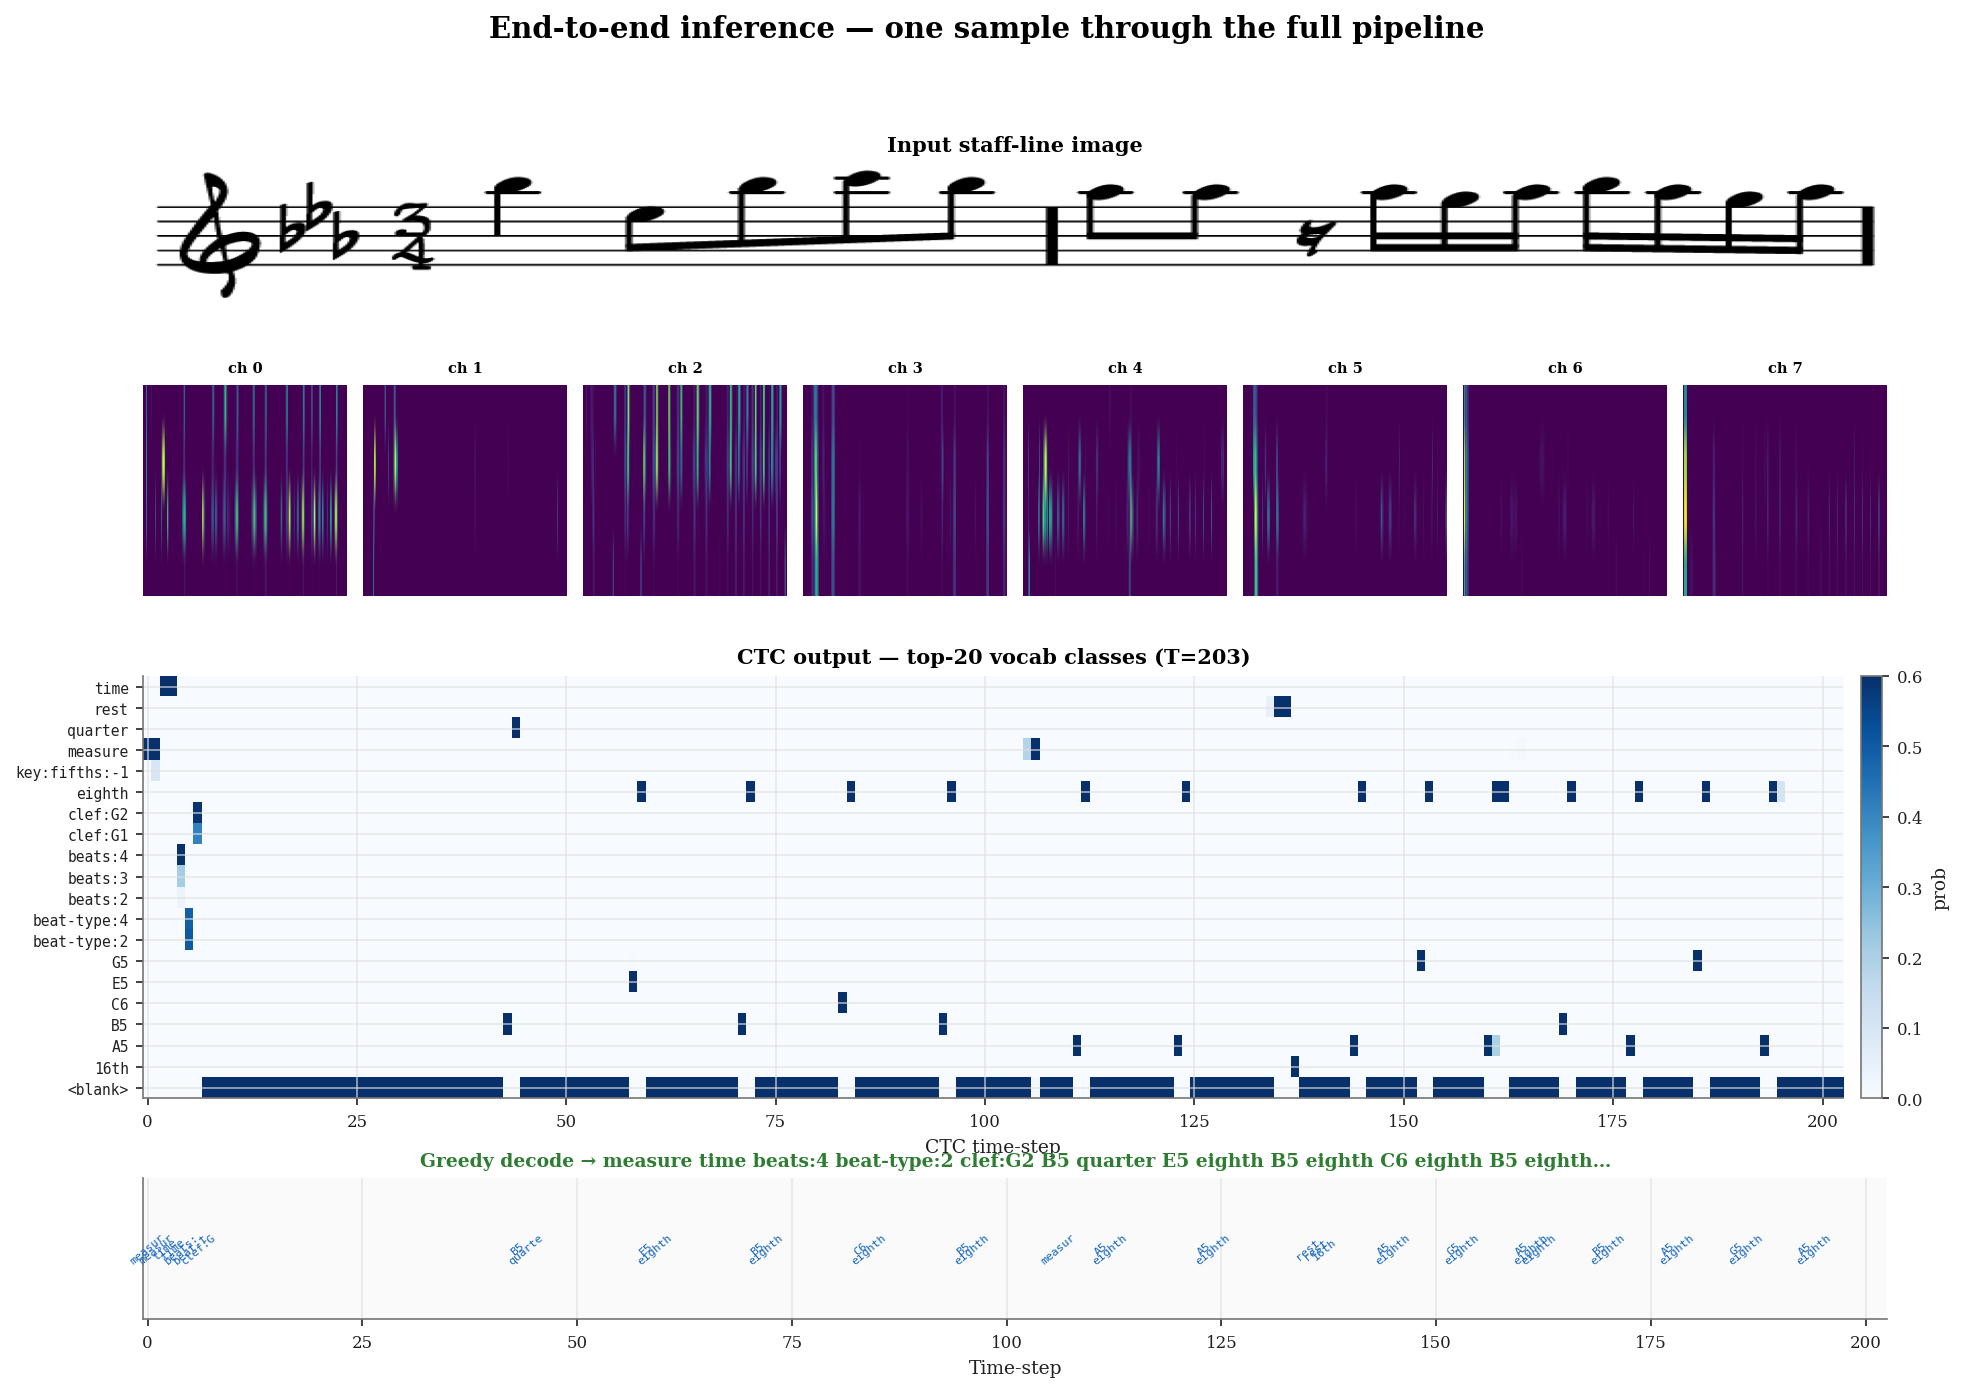

In [81]:
# ── Full pipeline visualisation: image + CNN features + CTC output ────────────
feat = cnn_features.get("output")
lp   = log_probs[:, 0, :].exp().cpu().numpy()
T_out, V = lp.shape
greedy_path = lp.argmax(axis=1)

# Top active vocab classes
top_idx  = sorted(lp.max(axis=0).argsort()[::-1][:20])
top_toks = [vocab._idx2tok[i] for i in top_idx]

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(4, 1, height_ratios=[1, 1.5, 3, 1], hspace=0.35)
fig.suptitle("End-to-end inference — one sample through the full pipeline",
             fontsize=14, fontweight="bold")

# ── Row 1: input image ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0])
ax.imshow(np.array(Image.open(SDIR / f"{SID}.png").convert("L")),
          cmap="gray", aspect="auto")
ax.set_title("Input staff-line image", fontsize=10, fontweight="bold")
ax.axis("off")

# ── Row 2: CNN feature maps (selection) ─────────────────────────────────────
if feat is not None:
    f0 = feat[0]  # (C, H', W')
    n_show, ncols = min(8, f0.shape[0]), 8
    inner_gs = gs[1].subgridspec(1, ncols, wspace=0.08)
    for i in range(ncols):
        ax = fig.add_subplot(inner_gs[i])
        if i < n_show:
            ax.imshow(f0[i].numpy(), cmap="viridis", aspect="auto")
            ax.set_title(f"ch {i}", fontsize=7)
        ax.axis("off")

# ── Row 3: CTC probability heatmap ──────────────────────────────────────────
ax = fig.add_subplot(gs[2])
im = ax.imshow(lp[:, top_idx].T, aspect="auto", cmap="Blues",
               origin="lower", vmin=0, vmax=0.6)
ax.set_yticks(range(len(top_idx)))
ax.set_yticklabels(top_toks, fontsize=7, family="monospace")
ax.set_xlabel("CTC time-step", fontsize=9)
ax.set_title(f"CTC output — top-20 vocab classes (T={T_out})", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label="prob")

# ── Row 4: decoded sequence ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[3])
ax.set_xlim(-0.5, T_out - 0.5); ax.set_ylim(-0.3, 1.3)
ax.set_yticks([]); ax.set_xlabel("Time-step", fontsize=9)
ax.set_facecolor(style.C["bg_figure"])
for t, idx in enumerate(greedy_path):
    tok = vocab._idx2tok[idx]
    if idx != vocab.blank_idx:
        ax.text(t, 0.5, tok[:6], ha="center", va="center",
                fontsize=5.5, family="monospace", color=style.C["primary"], rotation=40)
short_pred = " ".join(pred_toks[:15]) + ("…" if len(pred_toks) > 15 else "")
ax.set_title(f"Greedy decode → {short_pred}", fontsize=9,
             color=style.C["tertiary"], fontweight="bold")

plt.tight_layout()
plt.show()

## 10 — Results: Batch Evaluation on Test Samples

In [82]:
# Free unused GPU memory
if "model" in dir(): del model
torch.cuda.empty_cache()

# Evaluate on a random batch of test samples — compute per-sample SER
from CRNN_CTC.dataset import collate_fn, make_splits

_, _, test_ds = make_splits(
    cfg.data_dir, vocab,
    img_height=cfg.img_height, max_image_width=cfg.max_image_width,
    scanned_dir=None,
    val_frac=cfg.val_frac, test_frac=cfg.test_frac, seed=cfg.seed,
    filter_non_leadsheet_clef=cfg.filter_non_leadsheet_clef,
    filter_unusual_time=cfg.filter_unusual_time,
    filter_multi_staff=cfg.filter_multi_staff,
    max_source_height=cfg.max_source_height,
    extra_data_dirs=[DATA_AB],
    extra_scanned_dirs=None,
)

rng_eval = np.random.default_rng(42)
n_eval   = min(500, len(test_ds))
eval_idx = rng_eval.choice(len(test_ds), n_eval, replace=False)
eval_sub = torch.utils.data.Subset(test_ds, eval_idx)

sers, preds_list, refs_list = [], [], []
loader = torch.utils.data.DataLoader(eval_sub, batch_size=4,
                                      collate_fn=collate_fn, num_workers=0)

inf_model.eval()
with torch.inference_mode(), torch.amp.autocast("cuda"):
    for batch in loader:
        lp_b, ol_b = inf_model(batch["images"].to(DEVICE),
                                batch["image_widths"].to(DEVICE))
        decoded_b = greedy_decode(lp_b.cpu().float(), ol_b.cpu(), vocab)
        label_lens  = batch["label_lens"]
        labels_flat = batch["labels"]
        offset = 0
        for i, pred in enumerate(decoded_b):
            L = label_lens[i].item()
            ref_ids = labels_flat[offset:offset+L].tolist()
            ref = [vocab._idx2tok[r] for r in ref_ids]
            offset += L
            ed = _edit_distance(pred, ref)
            s  = ed / max(len(ref), 1)
            sers.append(s)
            preds_list.append(pred)
            refs_list.append(ref)

sers = np.array(sers)
print(f"Evaluated {n_eval} / {len(test_ds)} test samples")
print(f"  Mean SER     : {sers.mean()*100:.2f}%")
print(f"  Median SER   : {np.median(sers)*100:.2f}%")
print(f"  Perfect (0%) : {(sers == 0).sum()} / {n_eval}  ({(sers == 0).mean()*100:.1f}%)")
print(f"  SER ≤ 5%     : {(sers <= 0.05).sum()} / {n_eval}  ({(sers <= 0.05).mean()*100:.1f}%)")
print(f"  SER ≤ 10%    : {(sers <= 0.10).sum()} / {n_eval}  ({(sers <= 0.10).mean()*100:.1f}%)")

Evaluated 500 / 5757 test samples
  Mean SER     : 14.18%
  Median SER   : 10.53%
  Perfect (0%) : 32 / 500  (6.4%)
  SER ≤ 5%     : 108 / 500  (21.6%)
  SER ≤ 10%    : 238 / 500  (47.6%)


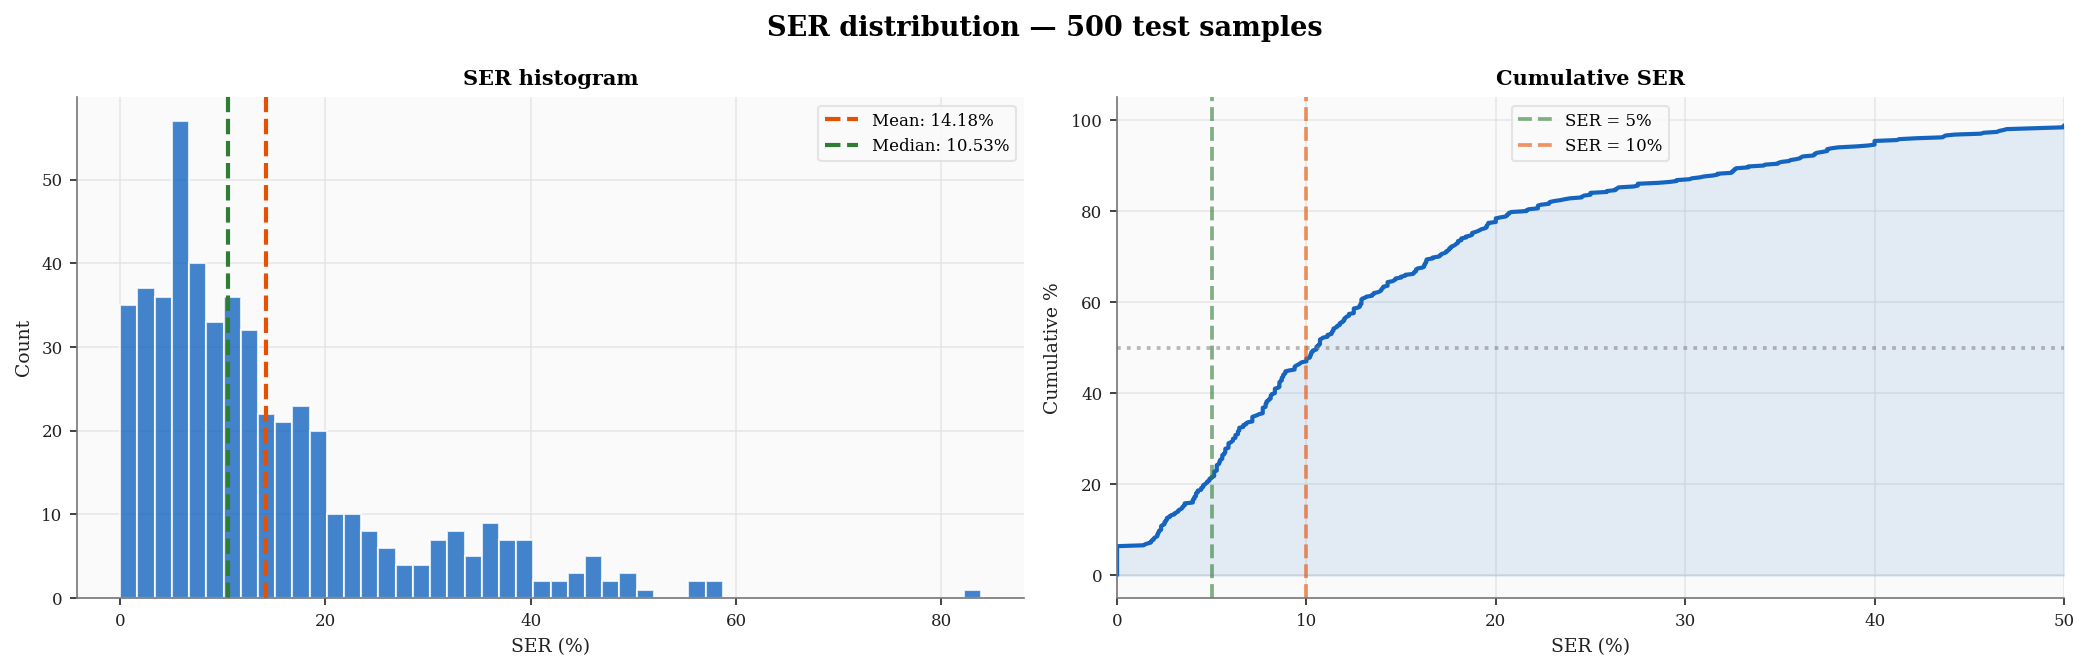

In [83]:
# SER distribution histogram + cumulative curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(f"SER distribution — {n_eval} test samples",
             fontsize=13, fontweight="bold")

# Histogram
ax1.hist(sers * 100, bins=50, color=style.C["primary"], alpha=0.8, edgecolor="white")
ax1.axvline(sers.mean() * 100, color=style.C["secondary"], ls="--", lw=2,
            label=f"Mean: {sers.mean()*100:.2f}%")
ax1.axvline(np.median(sers) * 100, color=style.C["tertiary"], ls="--", lw=2,
            label=f"Median: {np.median(sers)*100:.2f}%")
ax1.set_xlabel("SER (%)"); ax1.set_ylabel("Count")
ax1.set_title("SER histogram", fontsize=10)
ax1.legend(fontsize=8)

# Cumulative
sorted_sers = np.sort(sers) * 100
cumulative   = np.arange(1, len(sorted_sers) + 1) / len(sorted_sers) * 100
ax2.plot(sorted_sers, cumulative, color=style.C["primary"], lw=2)
ax2.axhline(50, ls=":", color=style.C["neutral_mid"], alpha=0.5)
ax2.axvline(5, ls="--", color=style.C["tertiary"], alpha=0.6, label="SER = 5%")
ax2.axvline(10, ls="--", color=style.C["secondary"], alpha=0.6, label="SER = 10%")
ax2.fill_between(sorted_sers, cumulative, alpha=0.1, color=style.C["primary"])
ax2.set_xlabel("SER (%)"); ax2.set_ylabel("Cumulative %")
ax2.set_title("Cumulative SER", fontsize=10)
ax2.set_xlim(0, min(50, sorted_sers.max() + 2))
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

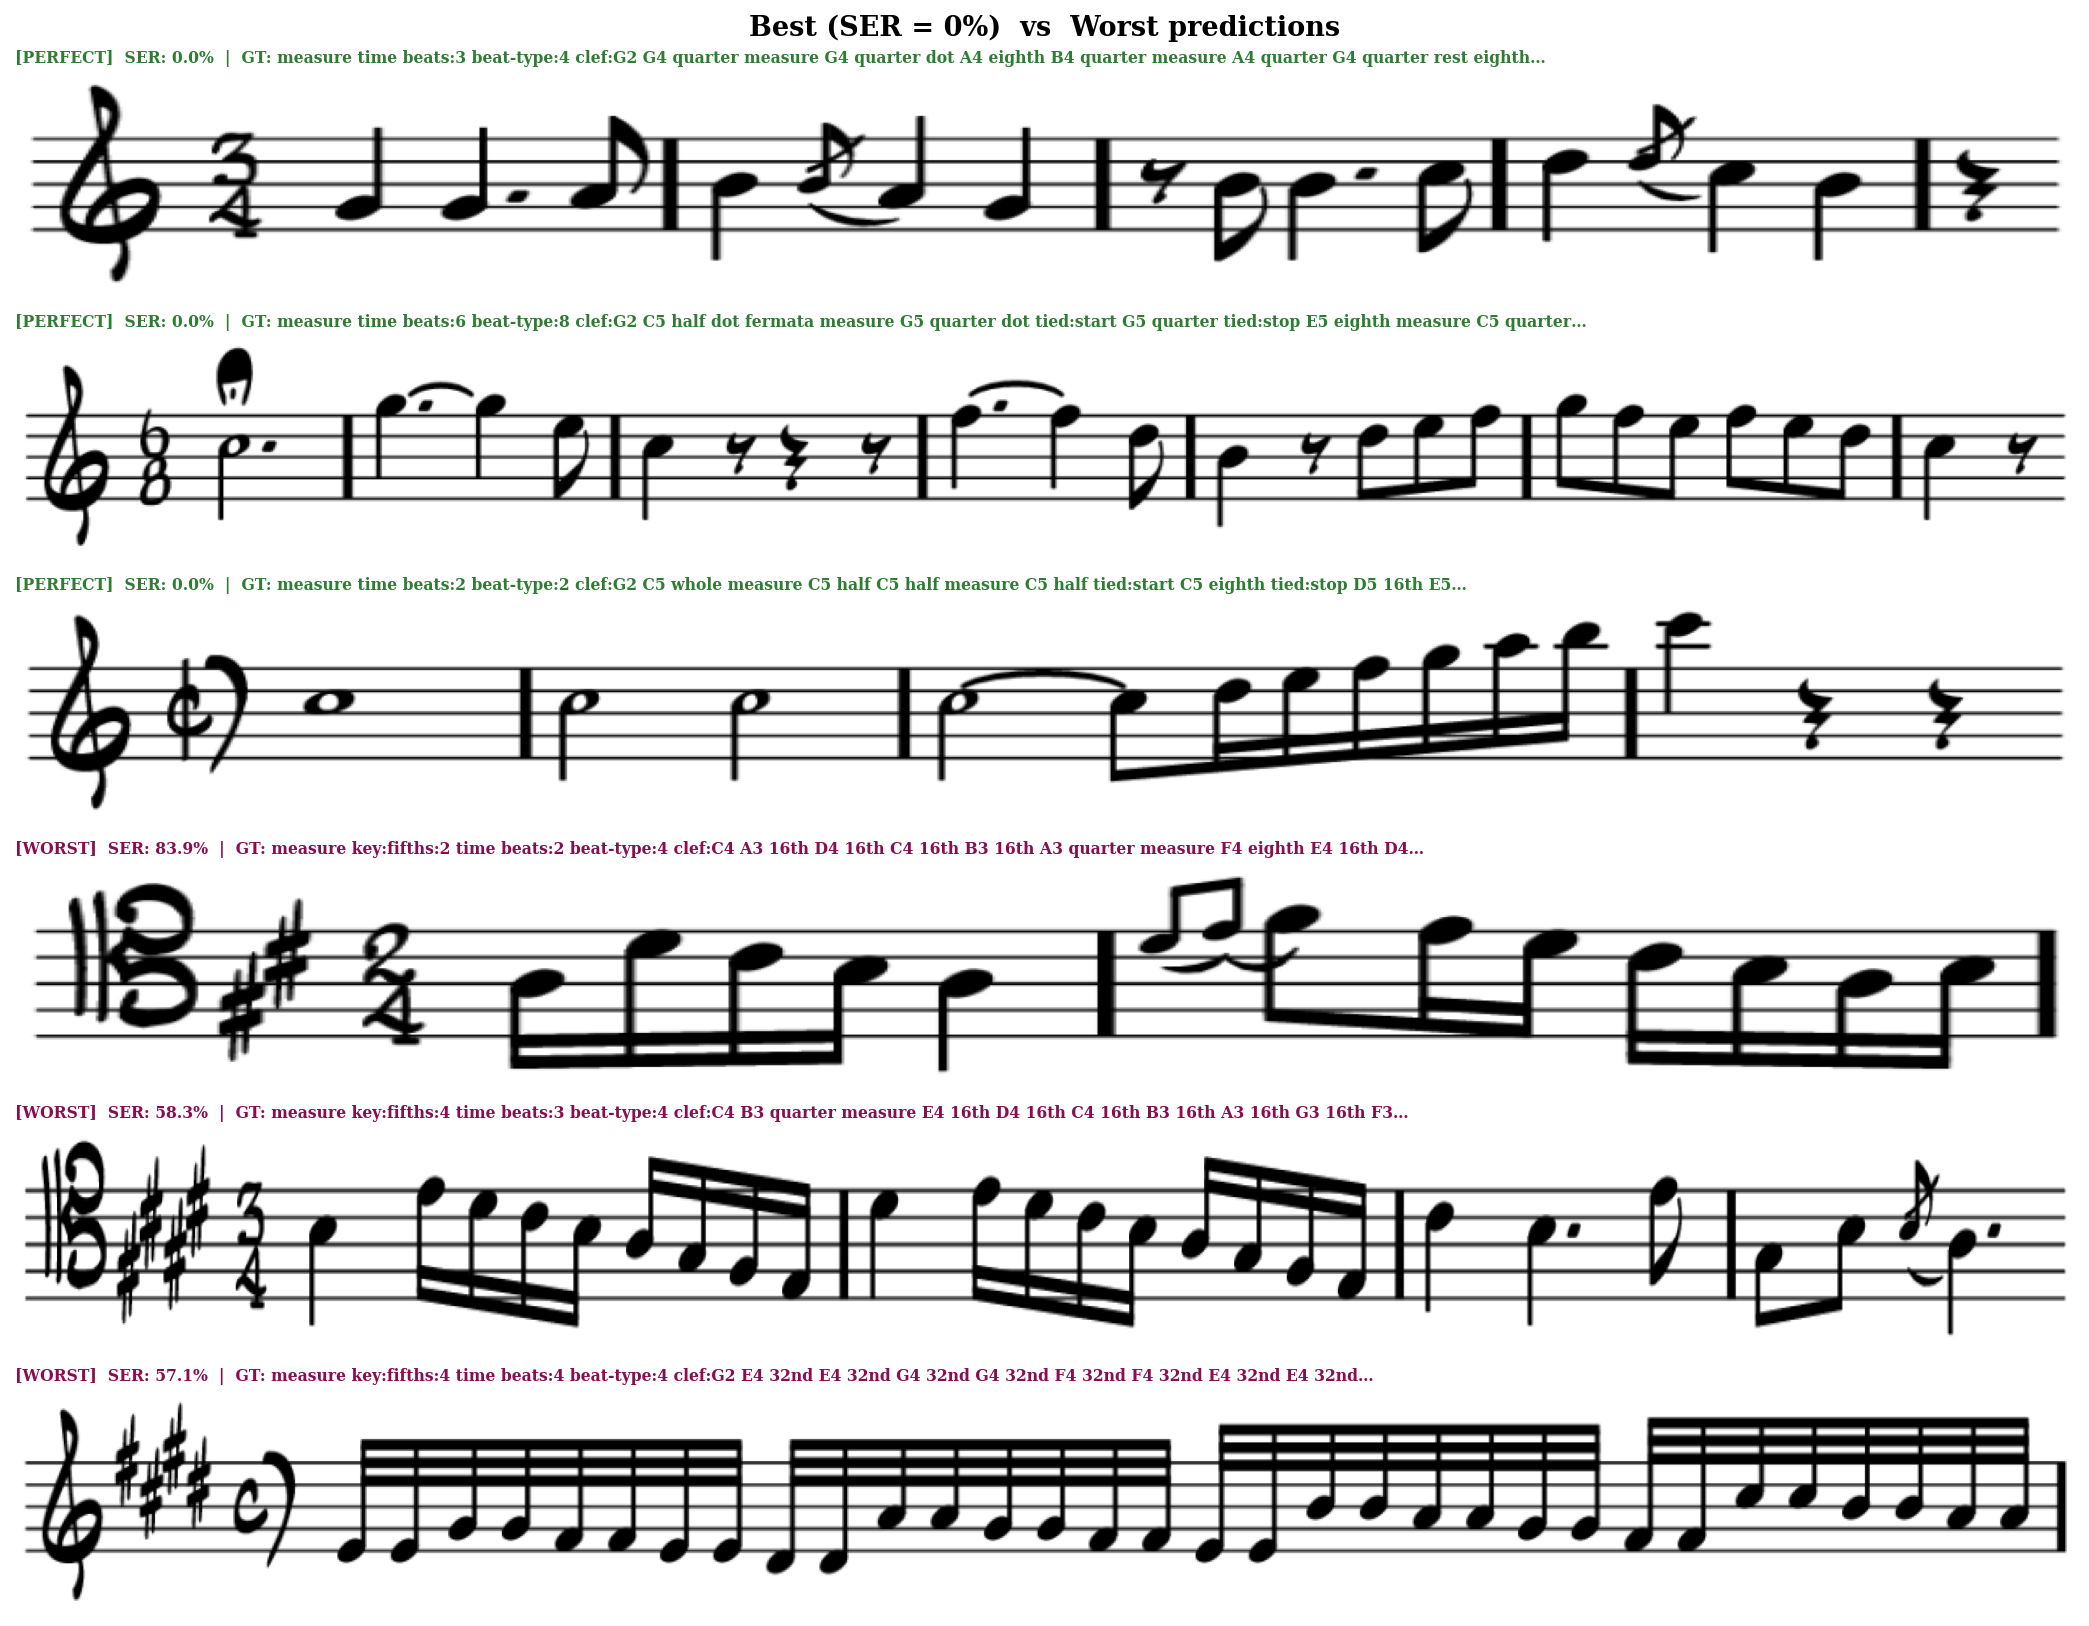

In [84]:
# 3 best predictions (SER=0) and 3 worst — visual comparison
order   = np.argsort(sers)
best_3  = order[:3]
worst_3 = order[-3:][::-1]

fig, axes = plt.subplots(6, 1, figsize=(14, 11))
fig.suptitle("Best (SER = 0%)  vs  Worst predictions",
             fontsize=13, fontweight="bold")

for row, (idx_arr, label_prefix, title_color) in enumerate([
    (best_3,  "PERFECT", style.C["tertiary"]),
    (worst_3, "WORST",   style.C["highlight"]),
]):
    for j, idx in enumerate(idx_arr):
        ax = axes[row * 3 + j]
        # Load image from the eval subset
        s_idx  = eval_idx[idx]
        sample = test_ds[s_idx]
        img_np = sample["image"].squeeze().numpy()

        ref  = refs_list[idx]
        pred = preds_list[idx]
        s    = sers[idx]

        ax.imshow(img_np, cmap="gray", aspect="auto")
        ax.axis("off")

        ref_str  = " ".join(ref[:22])  + ("…" if len(ref) > 22 else "")
        pred_str = " ".join(pred[:22]) + ("…" if len(pred) > 22 else "")

        ax.set_title(
            f"[{label_prefix}]  SER: {s*100:.1f}%  |  GT: {ref_str}",
            fontsize=7.5, loc="left", color=title_color, fontweight="bold")
        ax.set_xlabel(
            f"Pred: {pred_str}", fontsize=7, family="monospace",
            color=style.C["primary"], labelpad=2)

plt.tight_layout()
plt.show()